# EV Charging Station Placement for Greater Cairo
**K-center facility location solved with Particle Swarm Optimization (random-key encoding)**

Choose `K = 15` charging-station sites out of `200` candidates so that the
*farthest* neighborhood is as close as possible to its nearest station:

`minimize  max_i  min_{j in S}  d(i, j)`   subject to `|S| = K` and a minimum station spacing.

**Data note:** neighborhoods and candidate sites are *synthetic*, generated around
approximate coordinates of real Cairo districts. They are not real survey or GIS data.

The PSO is compared with two baselines using the same evaluation budget:
random search and a farthest-first K-center heuristic. A hybrid PSO that is seeded
with the heuristic's solution is also evaluated.

In [1]:
import json
import os
import sys
from dataclasses import dataclass, field

import folium
import matplotlib

matplotlib.use("Agg") if "ipykernel" not in sys.modules else None
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from folium import plugins
from scipy.spatial.distance import cdist

## 1. Configuration

In [2]:
SEED = 42                  # data generation + main run
NUM_NEIGHBORHOODS = 60
NUM_CANDIDATES = 200
NUM_STATIONS = 15
MIN_SPACING_KM = 0.5       # stations closer than this are penalised
PENALTY_PER_KM = 10.0      # fitness penalty (in km) per km of spacing violation

NUM_PARTICLES = 60
MAX_ITERATIONS = 200
W_START, W_END = 0.9, 0.4  # linearly decaying inertia weight
C1, C2 = 1.5, 1.5          # cognitive / social coefficients
V_MAX = 0.5                # velocity clamp (keys live in [0, 1])

NUM_BENCHMARK_RUNS = 20    # independent runs for PSO and random search
COVERAGE_KM = (2, 5, 10)   # coverage thresholds reported
OUT_DIR = "outputs"

## 2. Synthetic Cairo data

In [3]:
CENTER = (30.04444, 31.23583)  # (lat, lon)
KM_PER_DEG = 111.0

DISTRICTS = {
    "Downtown": (30.0475, 31.2358),
    "Garden City": (30.0400, 31.2280),
    "Zamalek": (30.0667, 31.2167),
    "Maadi": (29.9667, 31.2500),
    "Heliopolis": (30.1000, 31.3333),
    "Nasr City": (30.0667, 31.3000),
    "Dokki": (30.0375, 31.2100),
    "Mohandessin": (30.0450, 31.2000),
    "Abbassia": (30.0667, 31.2667),
    "Shubra": (30.0833, 31.2333),
    "Old Cairo": (30.0167, 31.2333),
    "Khan el-Khalili": (30.0500, 31.2667),
    "City of the Dead": (30.0333, 31.2833),
    "New Cairo": (30.0167, 31.4500),
    "6th October City": (29.9500, 30.9500),
}

LANDMARKS = {
    "Giza Pyramids": (29.9792, 31.1342),
    "Egyptian Museum": (30.0478, 31.2336),
    "Cairo Tower": (30.0458, 31.2242),
    "Al-Azhar Mosque": (30.0456, 31.2628),
}


def project_km(latlon):
    """Local equirectangular projection (km) around the Cairo center.

    1 degree of longitude is ~96 km at Cairo's latitude (not 111 km), so raw
    degree distances would distort east-west distances by about 15%.
    """
    latlon = np.asarray(latlon, dtype=float)
    y = (latlon[:, 0] - CENTER[0]) * KM_PER_DEG
    x = (latlon[:, 1] - CENTER[1]) * KM_PER_DEG * np.cos(np.radians(CENTER[0]))
    return np.column_stack([x, y])


def generate_cairo_data(num_neighborhoods=NUM_NEIGHBORHOODS,
                        num_candidates=NUM_CANDIDATES, seed=SEED):
    """Generate synthetic neighborhoods and candidate station sites.

    All randomness comes from one seeded generator, so results are reproducible.
    Neighborhoods: 70% clustered around a real district, 30% uniform in a
    +/-0.45 degree box. Candidates: all district centers, a regular grid, and
    random sites, for exactly `num_candidates` in total.
    """
    rng = np.random.default_rng(seed)
    box = 0.45
    district_names = list(DISTRICTS)
    district_xy = np.array(list(DISTRICTS.values()))

    neighborhoods, names = [], []
    for i in range(num_neighborhoods):
        if rng.random() < 0.7:
            j = rng.integers(len(district_names))
            lat, lon = district_xy[j] + rng.normal(0, box * 0.1, size=2)
            names.append(f"{district_names[j]} Area {i + 1}")
        else:
            lat = CENTER[0] + rng.uniform(-box, box)
            lon = CENTER[1] + rng.uniform(-box, box)
            names.append(f"Cairo Neighborhood {i + 1}")
        neighborhoods.append((lat, lon))

    candidates = [tuple(p) for p in district_xy]           # real district centers
    g = int(np.sqrt(0.5 * num_candidates))                 # regular grid
    for a in range(g):
        for b in range(g):
            candidates.append((CENTER[0] + (a - g / 2) * 2 * box / g,
                               CENTER[1] + (b - g / 2) * 2 * box / g))
    while len(candidates) < num_candidates:                # random fill
        candidates.append((CENTER[0] + rng.uniform(-box, box),
                           CENTER[1] + rng.uniform(-box, box)))
    candidates = candidates[:num_candidates]

    return np.array(neighborhoods), np.array(candidates), names

## 3. Problem definition and fitness

In [4]:
@dataclass
class Problem:
    neighborhoods: np.ndarray   # (N, 2) lat/lon
    candidates: np.ndarray      # (C, 2) lat/lon
    k: int = NUM_STATIONS
    min_spacing_km: float = MIN_SPACING_KM
    penalty_per_km: float = PENALTY_PER_KM
    D_nc: np.ndarray = field(init=False, repr=False)  # neighborhood -> candidate (km)
    D_cc: np.ndarray = field(init=False, repr=False)  # candidate -> candidate (km)

    def __post_init__(self):
        nb, cd = project_km(self.neighborhoods), project_km(self.candidates)
        self.D_nc = cdist(nb, cd)
        self.D_cc = cdist(cd, cd)
        np.fill_diagonal(self.D_cc, np.inf)

    def max_distance(self, idx):
        return self.D_nc[:, idx].min(axis=1).max()

    def min_spacing(self, idx):
        return self.D_cc[np.ix_(idx, idx)].min()

    def fitness(self, idx):
        """Max neighborhood-to-nearest-station distance (km) + spacing penalty."""
        idx = np.asarray(idx)
        shortfall = max(0.0, self.min_spacing_km - self.min_spacing(idx))
        return self.max_distance(idx) + self.penalty_per_km * shortfall

## 4. Discrete PSO (random-key encoding)

Each particle is a continuous vector of 200 "keys", one per candidate site.
A solution is decoded by taking the sites with the **K largest keys**
(random-key / smallest-position-value rule, Bean 1994). Because positions are
continuous, the textbook PSO update applies unchanged:

`v <- w*v + c1*r1*(pbest - x) + c2*r2*(gbest - x)`,  `x <- x + v`

Decoding guarantees every particle is a valid set of K *distinct* sites.

In [5]:
@dataclass
class PSOResult:
    best_idx: np.ndarray
    best_fitness: float
    history: list          # global best fitness per iteration (index 0 = initial swarm)
    mean_history: list     # swarm mean fitness per iteration
    evaluations: int


class DiscretePSO:
    def __init__(self, problem, num_particles=NUM_PARTICLES, iterations=MAX_ITERATIONS,
                 w_start=W_START, w_end=W_END, c1=C1, c2=C2, v_max=V_MAX, seed=None,
                 seed_solution=None, num_seeded=6, seed_noise=0.15):
        self.seed_solution, self.num_seeded, self.seed_noise = seed_solution, num_seeded, seed_noise
        self.p, self.P, self.T = problem, num_particles, iterations
        self.w_start, self.w_end, self.c1, self.c2, self.v_max = w_start, w_end, c1, c2, v_max
        self.rng = np.random.default_rng(seed)

    def _decode(self, X):
        return np.argpartition(-X, self.p.k - 1, axis=1)[:, :self.p.k]

    def _evaluate(self, X):
        return np.array([self.p.fitness(idx) for idx in self._decode(X)])

    def run(self):
        C = len(self.p.candidates)
        X = self.rng.random((self.P, C))
        if self.seed_solution is not None:   # hybrid: seed a few particles with a known solution
            for i in range(self.num_seeded):
                keys = self.rng.random(C) * 0.5
                keys[self.seed_solution] = 0.5 + self.rng.random(len(self.seed_solution)) * 0.5
                X[i] = keys if i == 0 else keys + self.rng.normal(0, self.seed_noise, C)
        V = self.rng.uniform(-self.v_max, self.v_max, (self.P, C))
        fit = self._evaluate(X)
        pbest, pfit = X.copy(), fit.copy()
        g = int(np.argmin(pfit))
        gbest, gfit = pbest[g].copy(), float(pfit[g])
        history, mean_history = [gfit], [float(fit.mean())]

        for t in range(1, self.T + 1):
            w = self.w_start - (self.w_start - self.w_end) * t / self.T
            r1, r2 = self.rng.random((self.P, C)), self.rng.random((self.P, C))
            V = w * V + self.c1 * r1 * (pbest - X) + self.c2 * r2 * (gbest - X)
            V = np.clip(V, -self.v_max, self.v_max)
            X = X + V
            fit = self._evaluate(X)

            better = fit < pfit
            pbest[better], pfit[better] = X[better], fit[better]
            g = int(np.argmin(pfit))
            if pfit[g] < gfit:
                gbest, gfit = pbest[g].copy(), float(pfit[g])

            history.append(gfit)
            mean_history.append(float(fit.mean()))

        best_idx = np.sort(self._decode(gbest[None, :])[0])
        return PSOResult(best_idx, gfit, history, mean_history, self.P * (self.T + 1))

## 5. Baselines: random search and farthest-first K-center

In [6]:
def random_search(problem, num_evals, batch=NUM_PARTICLES, seed=None):
    """Evaluate `num_evals` random K-subsets; history is best-so-far per `batch`."""
    rng = np.random.default_rng(seed)
    C, best, best_idx, history, done = len(problem.candidates), np.inf, None, [], 0
    while done < num_evals:
        for _ in range(min(batch, num_evals - done)):
            idx = rng.choice(C, problem.k, replace=False)
            f = problem.fitness(idx)
            if f < best:
                best, best_idx = f, idx
        done += batch
        history.append(best)
    return np.sort(best_idx), best, history


def farthest_first_k_center(problem):
    """Gonzalez-style farthest-first heuristic restricted to candidate sites.

    Start with the site closest to everyone on average, then repeatedly find the
    worst-served neighborhood and open the nearest unused candidate site to it.
    Deterministic, instant, and a strong baseline for the K-center objective.
    """
    chosen = [int(np.argmin(problem.D_nc.mean(axis=0)))]
    cur = problem.D_nc[:, chosen[0]].copy()
    while len(chosen) < problem.k:
        worst = int(cur.argmax())
        j = next(c for c in np.argsort(problem.D_nc[worst]) if c not in chosen)
        chosen.append(int(j))
        cur = np.minimum(cur, problem.D_nc[:, j])
    idx = np.sort(chosen)
    return idx, problem.fitness(idx)

## 6. Metrics

In [7]:
def compute_metrics(problem, idx):
    d_all = problem.D_nc[:, idx]
    d = d_all.min(axis=1)
    m = {
        "max_distance_km": float(d.max()),
        "mean_distance_km": float(d.mean()),
        "median_distance_km": float(np.median(d)),
        "std_distance_km": float(d.std()),
        "min_station_spacing_km": float(problem.min_spacing(idx)),
        "num_stations": int(len(idx)),
        "num_neighborhoods": int(len(d)),
    }
    for r in COVERAGE_KM:
        m[f"coverage_{r}km_pct"] = float((d <= r).mean() * 100)
    return m, d, d_all.argmin(axis=1)

## 7. Visualization and outputs

In [8]:
def nearest_district(lat, lon):
    pts = np.array(list(DISTRICTS.values()))
    d = np.linalg.norm(project_km(pts) - project_km([(lat, lon)])[0], axis=1)
    return list(DISTRICTS)[int(d.argmin())]


def plot_results(histories, ff_fit, runs, path):
    """histories: {label: list}; runs: {label: list of final max distances}."""
    colors = {"PSO": "tab:blue", "PSO + farthest-first seeding": "tab:purple", "Random search": "gray"}
    fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
    for label, h in histories.items():
        ax[0].plot(h, lw=2, color=colors.get(label), label=label)
    ax[0].axhline(ff_fit, color="green", ls="--", label=f"Farthest-first heuristic ({ff_fit:.2f} km)")
    ax[0].set_xlabel("Iteration (1 iteration = 60 evaluations)")
    ax[0].set_ylabel("Best max distance (km)")
    ax[0].set_title("Convergence (main run)")
    ax[0].grid(alpha=0.3)
    ax[0].legend()

    bp = ax[1].boxplot(list(runs.values()), showmeans=True)
    ax[1].set_xticklabels([l.replace(" + ", "\n+ ") for l in runs], fontsize=9)
    ax[1].axhline(ff_fit, color="green", ls="--", label="Farthest-first heuristic")
    ax[1].set_ylabel("Final max distance (km)")
    ax[1].set_title(f"Final fitness over {len(next(iter(runs.values())))} independent runs")
    ax[1].grid(alpha=0.3)
    ax[1].legend()
    fig.tight_layout()
    fig.savefig(path, dpi=150)
    plt.close(fig) if "ipykernel" not in sys.modules else plt.show()


def create_cairo_map(problem, names, idx, assign, metrics, path):
    m = folium.Map(location=list(CENTER), zoom_start=10, tiles="OpenStreetMap")
    m.get_root().html.add_child(folium.Element(
        "<h3 align='center' style='font-size:16px'><b>Optimized EV charging stations - Greater Cairo (synthetic data)</b></h3>"
        f"<h4 align='center' style='font-size:12px'>Max distance to nearest station: "
        f"{metrics['max_distance_km']:.1f} km | mean {metrics['mean_distance_km']:.1f} km</h4>"))

    layers = {k: folium.FeatureGroup(name=k, show=s) for k, s in [
        ("Districts", True), ("Neighborhoods", True), ("Stations", True),
        ("Assignment lines", True), ("Covering radius", False), ("Landmarks", False)]}
    stations = problem.candidates[idx]

    for name, (lat, lon) in DISTRICTS.items():
        folium.CircleMarker([lat, lon], radius=3, color="purple", fill=True, fill_opacity=0.5,
                            weight=1, popup=f"<b>{name}</b><br>District center").add_to(layers["Districts"])
    for i, (lat, lon) in enumerate(problem.neighborhoods):
        s = stations[assign[i]]
        dist = problem.D_nc[i, idx[assign[i]]]
        folium.CircleMarker([lat, lon], radius=5, color="blue", fill=True, fill_opacity=0.6, weight=1,
                            popup=f"<b>{names[i]}</b><br>Nearest station #{assign[i] + 1}: {dist:.2f} km"
                            ).add_to(layers["Neighborhoods"])
        folium.PolyLine([[lat, lon], list(s)], color="gray", weight=1, opacity=0.4).add_to(layers["Assignment lines"])
    for i, (lat, lon) in enumerate(stations):
        served = int((assign == i).sum())
        folium.Marker([lat, lon], tooltip=f"Station {i + 1}",
                      popup=f"<b>Station {i + 1}</b><br>Near: {nearest_district(lat, lon)}<br>Serves {served} neighborhoods",
                      icon=folium.Icon(color="green", icon="bolt", prefix="fa")).add_to(layers["Stations"])
        folium.Circle([lat, lon], radius=metrics["max_distance_km"] * 1000, color="green",
                      weight=1, fill=True, fill_opacity=0.04).add_to(layers["Covering radius"])
    for name, (lat, lon) in LANDMARKS.items():
        folium.Marker([lat, lon], tooltip=name, icon=folium.Icon(color="orange", icon="info-sign")
                      ).add_to(layers["Landmarks"])

    for layer in layers.values():
        layer.add_to(m)
    folium.LayerControl(collapsed=False).add_to(m)
    plugins.Fullscreen().add_to(m)
    m.save(path)

## 8. Run everything

EV CHARGING STATION PLACEMENT - GREATER CAIRO (PSO)
Neighborhoods: 60 | candidates: 200 | stations: 15 | evaluations per run: 12060



Delivered solution: PSO + farthest-first seeding (seed 42)
  max distance  : 10.40 km
  mean / median : 5.11 / 5.02 km
  coverage      : <=2 km: 8.3%, <=5 km: 48.3%, <=10 km: 96.7%
  min spacing   : 9.99 km
  plain PSO main run: 19.03 km (initial swarm best) -> 12.69 km (33.3% better)

Benchmark: 20 independent runs, 12060 evaluations each:
                                  Method  Mean max dist (km)  Std (km)  Best (km)
                                     PSO               13.05      1.32      11.29
            PSO + farthest-first seeding               10.34      0.10      10.16
                           Random search               15.07      0.62      13.86
Farthest-first heuristic (deterministic)               10.40      0.00      10.40


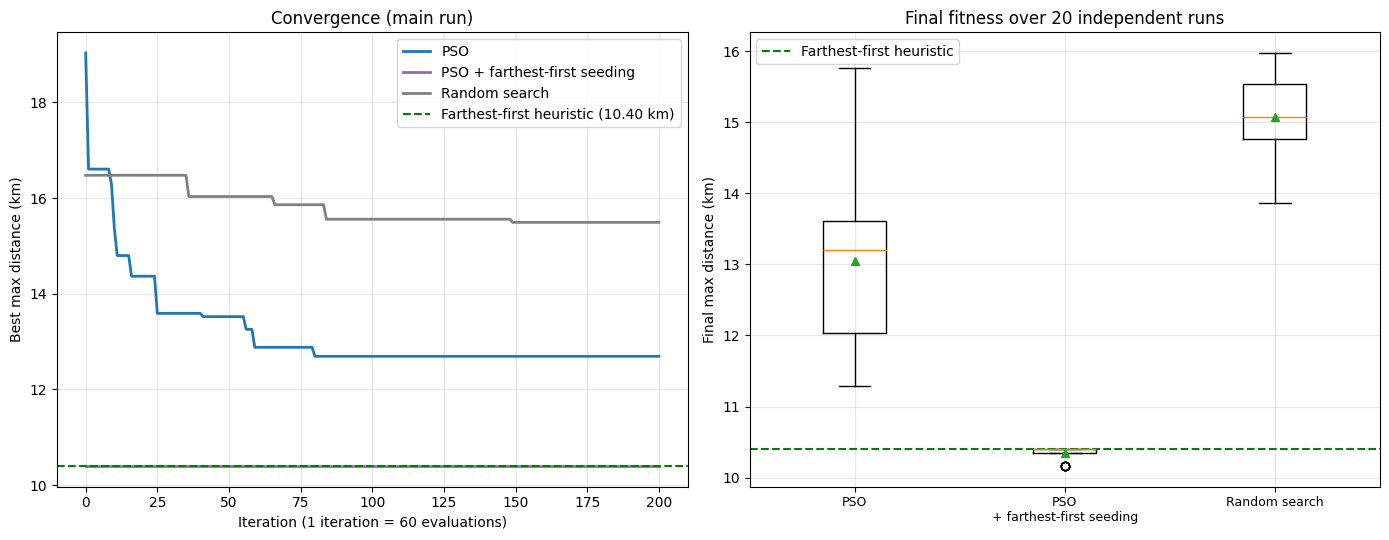


Saved outputs to ./outputs/


In [9]:
def main(open_map=False, out_dir=OUT_DIR):
    os.makedirs(out_dir, exist_ok=True)
    print("=" * 62)
    print("EV CHARGING STATION PLACEMENT - GREATER CAIRO (PSO)")
    print("=" * 62)

    neighborhoods, candidates, names = generate_cairo_data()
    problem = Problem(neighborhoods, candidates)
    budget = NUM_PARTICLES * (MAX_ITERATIONS + 1)
    print(f"Neighborhoods: {len(neighborhoods)} | candidates: {len(candidates)} | "
          f"stations: {NUM_STATIONS} | evaluations per run: {budget}")

    # baselines and main runs (seed SEED)
    ff_idx, ff_fit = farthest_first_k_center(problem)
    pso = DiscretePSO(problem, seed=SEED).run()
    hyb = DiscretePSO(problem, seed=SEED, seed_solution=ff_idx).run()
    rs_idx, rs_fit, rs_hist = random_search(problem, budget, seed=SEED)

    # independent benchmark runs
    R = range(NUM_BENCHMARK_RUNS)
    runs = {
        "PSO": [DiscretePSO(problem, seed=1000 + r).run().best_fitness for r in R],
        "PSO + farthest-first seeding": [DiscretePSO(problem, seed=3000 + r, seed_solution=ff_idx).run().best_fitness for r in R],
        "Random search": [random_search(problem, budget, seed=2000 + r)[1] for r in R],
    }

    # the delivered solution (map + CSVs) is the best of the two PSO variants in the main run
    final = hyb if hyb.best_fitness <= pso.best_fitness else pso
    final_name = "PSO + farthest-first seeding" if final is hyb else "PSO"
    metrics, d, assign = compute_metrics(problem, final.best_idx)
    pso_metrics, *_ = compute_metrics(problem, pso.best_idx)
    ff_metrics, *_ = compute_metrics(problem, ff_idx)
    rs_metrics, *_ = compute_metrics(problem, rs_idx)

    print(f"\nDelivered solution: {final_name} (seed {SEED})")
    print(f"  max distance  : {metrics['max_distance_km']:.2f} km")
    print(f"  mean / median : {metrics['mean_distance_km']:.2f} / {metrics['median_distance_km']:.2f} km")
    print("  coverage      : " + ", ".join(f"<={r} km: {metrics[f'coverage_{r}km_pct']:.1f}%" for r in COVERAGE_KM))
    print(f"  min spacing   : {metrics['min_station_spacing_km']:.2f} km")
    print(f"  plain PSO main run: {pso.history[0]:.2f} km (initial swarm best) -> "
          f"{pso.best_fitness:.2f} km ({(pso.history[0] - pso.best_fitness) / pso.history[0] * 100:.1f}% better)")

    rows = [(k, np.mean(v), np.std(v), np.min(v)) for k, v in runs.items()]
    rows.append(("Farthest-first heuristic (deterministic)", ff_fit, 0.0, ff_fit))
    summary = pd.DataFrame(rows, columns=["Method", "Mean max dist (km)", "Std (km)", "Best (km)"]).round(2)
    print(f"\nBenchmark: {NUM_BENCHMARK_RUNS} independent runs, {budget} evaluations each:")
    print(summary.to_string(index=False))

    # outputs
    plot_results({"PSO": pso.history, "PSO + farthest-first seeding": hyb.history,
                  "Random search": rs_hist}, ff_fit, runs,
                 os.path.join(out_dir, "cairo_ev_convergence.png"))
    map_path = os.path.join(out_dir, "cairo_ev_charging_map.html")
    create_cairo_map(problem, names, final.best_idx, assign, metrics, map_path)

    stations = problem.candidates[final.best_idx]
    pd.DataFrame({
        "Station_ID": range(1, len(stations) + 1),
        "Latitude": stations[:, 0].round(5), "Longitude": stations[:, 1].round(5),
        "Index_in_Candidates": final.best_idx,
        "Nearest_District": [nearest_district(*s) for s in stations],
        "Neighborhoods_Served": [int((assign == i).sum()) for i in range(len(stations))],
    }).to_csv(os.path.join(out_dir, "cairo_optimal_stations.csv"), index=False)
    pd.DataFrame({
        "Neighborhood": names, "Latitude": neighborhoods[:, 0].round(5),
        "Longitude": neighborhoods[:, 1].round(5),
        "Assigned_Station": assign + 1, "Distance_km": d.round(3),
    }).to_csv(os.path.join(out_dir, "cairo_neighborhoods.csv"), index=False)
    summary.to_csv(os.path.join(out_dir, "cairo_benchmark.csv"), index=False)
    with open(os.path.join(out_dir, "cairo_results.json"), "w") as f:
        json.dump({"delivered_solution": final_name, "delivered_metrics": metrics,
                   "pso_main": pso_metrics, "farthest_first": ff_metrics, "random_search_main": rs_metrics,
                   "runs_max_km": runs, "pso_initial_best_km": pso.history[0],
                   "evaluations_per_run": budget}, f, indent=2)
    print(f"\nSaved outputs to ./{out_dir}/")

    if open_map:
        import webbrowser
        webbrowser.open("file://" + os.path.realpath(map_path))
    return final, metrics, summary


if __name__ == "__main__":
    main(open_map="--open" in sys.argv)